# Mirror-CFE Decoder Training — Fashion-MNIST Trouser vs. Dress

Faithful-Port des **Chest-X-Ray** Mirror-Decoder-Notebooks auf den einfacheren Fashion-MNIST-Datensatz (Trouser/Dress) und den lokal trainierten **ResNet-18** (`fashionmnist_trouser_dress_resnet18.pth`). Architektur (SSC = SPE + CSP, SkipDecoder, PatchGAN) und alle Losses sind **identisch** zur X-Ray-Version. Geaendert ist nur, was das neue ResNet bzw. 28x28/1-Kanal erzwingt:
- Klassifikator-Zugriff ueber torchvision-Module (`layer1..4`, `fc`) statt `encoder.blocks` / `decoder.decoder`.
- Feature-Groessen 64/28, 128/14, 256/7, 512/4 (statt 64/56, 128/28, 256/14, 512/7).
- SPE-Bottleneck poolt auf die f4-Groesse 4x4; Decoder-up-path 4->7->14->28; 1-Kanal-Ausgang/Diskriminator; Fashion-MNIST-Normalisierung.

## 1. Imports & Konfiguration

In [1]:
import os
import ssl
import time
import numpy as np
from pathlib import Path
from tqdm import tqdm

# macOS-Python ohne CA-Zertifikate -> MNIST-Download via certifi absichern
try:
    import certifi
    ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
except ImportError:
    ssl._create_default_https_context = ssl._create_unverified_context

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from torchvision.models import resnet18

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Geraet:', DEVICE)

# ── Pfade (lokal) ─────────────────────────────────────────────────────────────
PROJ = Path.cwd()
while PROJ.name and not (PROJ / 'fashionmnist_trouser_dress_resnet18.pth').exists() and PROJ != PROJ.parent:
    PROJ = PROJ.parent
DATA_DIR = PROJ / 'data'
PTH_PATH = PROJ / 'fashionmnist_trouser_dress_resnet18.pth'
OUT_DIR  = PROJ / 'Counterfactuals' / 'Mirror'

IMG_SIZE    = 28
BATCH_SIZE  = 16
MEAN, STD   = 0.2860, 0.3530
DIGITS      = (1, 3)   # Trouser=1, Dress=3
# Trouser -> Klasse 0, Dress -> Klasse 1
CLASS_NAMES = {0: 'Trouser', 1: 'Dress'}

# ── Mirror-Decoder Hyperparameter (identisch zur X-Ray-Version) ───────────────
DEC_LR      = 2e-4
DISC_LR     = 2e-4
DEC_EPOCHS  = 15
ALPHA       = 0.2          # Triangulation-Relaxation (Paper-Default)
RHO_L       = 0.1          # CSP Maskenschwelle untere Grenze
RHO_U       = 0.5          # CSP Maskenschwelle obere Grenze

# Loss-Gewichte (Paper: gleich, ausser L_tri=2)
W_CLS  = 1.0
W_ADV  = 1.0
W_REC  = 1.0
W_FEA  = 1.0
W_TRI  = 2.0

print('Modell vorhanden:', PTH_PATH.exists(), '->', PTH_PATH)

Geraet: mps
Modell vorhanden: True -> /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/fashionmnist_trouser_dress_resnet18.pth


## 2. Datensatz — Fashion-MNIST Trouser vs. Dress

Ersetzt den NIH-CSV-/Patienten-Split der X-Ray-Version. Nur die Klassen Trouser und Dress, Label Trouser->0, Dress->1.

In [2]:
tfm_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])
# leichte Augmentierung fuers Decoder-Training (Pendant zu ColorJitter/Flip bei X-Ray)
tfm_train = transforms.Compose([
    transforms.RandomAffine(degrees=8, translate=(0.06, 0.06)),
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

def mnist_subset(train, transform):
    ds = datasets.FashionMNIST(root=str(DATA_DIR), train=train, download=True, transform=transform)
    idx = torch.where((ds.targets == DIGITS[0]) | (ds.targets == DIGITS[1]))[0]
    ds.targets = (ds.targets == DIGITS[1]).long()
    return Subset(ds, idx.tolist())

train_dataset = mnist_subset(train=True,  transform=tfm_train)
val_dataset   = mnist_subset(train=False, transform=tfm_eval)
print(f'Train: {len(train_dataset)}  Val: {len(val_dataset)}')

Train: 12000  Val: 2000


## 3. DataLoader

In [3]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0)

imgs, lbls = next(iter(train_loader))
print('Batch:', imgs.shape, '| Labels:', torch.unique(lbls, return_counts=True))
print(f'Train-Batches: {len(train_loader)}  Val-Batches: {len(val_loader)}')

Batch: torch.Size([16, 1, 28, 28]) | Labels: (tensor([0, 1]), tensor([ 4, 12]))
Train-Batches: 750  Val-Batches: 125


## 4. Klassifikator laden

Statt des custom-ResNet wird das lokal trainierte **torchvision-ResNet-18** geladen (1-Kanal-Stem, kein MaxPool, fc->2) und eingefroren.

In [4]:
def build_classifier():
    m = resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(512, 2)
    return m

classifier = build_classifier().to(DEVICE)
classifier.load_state_dict(torch.load(PTH_PATH, map_location=DEVICE))
classifier.eval()
for param in classifier.parameters():
    param.requires_grad = False

# Test-Accuracy zur Kontrolle
correct = total = 0
with torch.no_grad():
    for x, y in val_loader:
        pred = classifier(x.to(DEVICE)).argmax(1).cpu()
        correct += (pred == y).sum().item(); total += y.numel()
print(f'Klassifikator geladen und eingefroren | Test-Acc: {correct/total:.4f}')

Klassifikator geladen und eingefroren | Test-Acc: 0.9890


## 5. Feature-Extraktion & Mirror-Geometrie

`extract_all_features` haengt sich an `layer1..4` (statt `encoder.blocks`), `get_boundary_params`/`predict_probs_from_z` nutzen `fc` (statt `decoder.decoder`). `compute_flk` ist unveraendert.

In [5]:
def extract_all_features(model, images):
    """Feature Maps aus allen 4 ResNet-Ebenen.
       f1:(B,64,28,28) f2:(B,128,14,14) f3:(B,256,7,7) f4:(B,512,4,4)"""
    feats = {}
    hooks = []
    layer_map = {
        'f1': model.layer1,
        'f2': model.layer2,
        'f3': model.layer3,
        'f4': model.layer4,
    }
    for name, layer in layer_map.items():
        h = layer.register_forward_hook(
            lambda m, i, o, n=name: feats.update({n: o})
        )
        hooks.append(h)
    with torch.no_grad():
        _ = model(images)
    for h in hooks:
        h.remove()
    return feats['f1'], feats['f2'], feats['f3'], feats['f4']

def get_boundary_params(model):
    """Mirror-Hyperebene: Wm = W[1]-W[0], bm = b[1]-b[0] (Richtung Klasse 1)."""
    W  = model.fc.weight.data   # (2, 512)
    b  = model.fc.bias.data     # (2,)
    Wm = (W[1] - W[0]).clone()  # (512,)
    bm = (b[1] - b[0]).clone()  # scalar
    return Wm, bm

def gap(fmap):
    return F.adaptive_avg_pool2d(fmap, (1, 1)).flatten(1)

def compute_flk(f4_s, zs, Wm, bm, k):
    """Supp. Eq. 16/17: f^l_k = f^l_s + z_delta, broadcast ueber H,W.
       Garantiert GAP(f^l_k) = z_k."""
    B, C, H, Wd = f4_s.shape
    W_hat = Wm / (Wm.norm() + 1e-8)
    dot   = (Wm.view(1, C) * zs).sum(1, keepdim=True) + bm
    z_delta = -2.0 * k * dot * W_hat.view(1, C)
    zk  = zs + z_delta
    flk = f4_s + z_delta.view(B, C, 1, 1)
    return flk, zk

def predict_probs_from_z(model, z):
    """Softmax-Wahrscheinlichkeiten direkt aus einem GAP-Latent z (B,512)."""
    return torch.softmax(model.fc(z), dim=1)

# Sanity Check: GAP(f^l_k) == z_k
with torch.no_grad():
    _imgs, _ = next(iter(val_loader))
    _imgs = _imgs.to(DEVICE)
    _f1, _f2, _f3, _f4 = extract_all_features(classifier, _imgs)
    _zs = gap(_f4)
    _Wm, _bm = get_boundary_params(classifier); _Wm, _bm = _Wm.to(DEVICE), _bm.to(DEVICE)
    _flk, _zk = compute_flk(_f4, _zs, _Wm, _bm, k=0.8)
    err = (gap(_flk) - _zk).abs().max().item()
    print(f'Sanity: max|GAP(f^l_k) - z_k| = {err:.2e}  (sollte ~0 sein)')

Sanity: max|GAP(f^l_k) - z_k| = 4.77e-07  (sollte ~0 sein)


## 6. Skip-Connection-Controller (SSC)

Identisch zur X-Ray-Version; nur `Hi` (28/14/7 statt 56/28/14), die SPE-Bottleneck-Poolgroesse (4x4 = f4) und die CSP-Zielgroessen sind an die Fashion-MNIST-Feature-Maps angepasst.

In [6]:
# MPS unterstuetzt adaptive_avg_pool2d nur fuer teilbare Groessen (z.B. 14->4 nicht).
# Fuer genau diesen Schritt auf MPS auf CPU ausweichen -> identische Avg-Pool-Mathematik.
def _safe_adaptive_pool(x, size):
    if x.device.type == 'mps':
        return F.adaptive_avg_pool2d(x.cpu(), size).to(x.device)
    return F.adaptive_avg_pool2d(x, size)


class SPEBlock(nn.Module):
    """Spatial Pattern Editor fuer eine Skip-Ebene (Paper Eq. 12)."""
    def __init__(self, Ci, Hi, flk_ch=512, bottleneck_ch=128, flk_hw=4):
        super().__init__()
        self.Hi = Hi
        self.flk_hw = flk_hw
        # B_i: Quell-Skip-Feature -> (bottleneck_ch, flk_hw, flk_hw) = f4-Groesse.
        # Adaptive-Pool MPS-sicher in forward (s.o.).
        self.bottleneck = nn.Sequential(
            nn.Conv2d(Ci, bottleneck_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(bottleneck_ch),
            nn.ReLU(inplace=True),
        )
        # D_i: concat(bottleneck, f^l_k) -> zurueck auf (Ci, Hi, Hi)
        self.decoder = nn.Sequential(
            nn.Conv2d(bottleneck_ch + flk_ch, Ci, kernel_size=3, padding=1),
            nn.BatchNorm2d(Ci),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(Hi, Hi), mode='bilinear', align_corners=False),
            nn.Conv2d(Ci, Ci, kernel_size=3, padding=1),
            nn.BatchNorm2d(Ci),
            nn.ReLU(inplace=True),
        )
    def forward(self, fi_s, flk):
        bi  = self.bottleneck(fi_s)                              # (B, bn, Hi, Hi)
        bi  = _safe_adaptive_pool(bi, (self.flk_hw, self.flk_hw))# (B, bn, 4, 4)
        cat = torch.cat([bi, flk], dim=1)                       # (B, bn+512, 4, 4)
        ui  = self.decoder(cat)                                 # (B, Ci, Hi, Hi)
        return ui


class SSC(nn.Module):
    """Skip-Connection-Controller = SPE (3 Ebenen) + CSP-Maskierung."""
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.rho_l = rho_l
        self.rho_u = rho_u
        # SPE-Bloecke fuer f1,f2,f3 (f4 = f^l_k ist Haupteingang)
        self.spe1 = SPEBlock(64,  28)
        self.spe2 = SPEBlock(128, 14)
        self.spe3 = SPEBlock(256, 7)

    def csp_mask(self, flk, W, k, target_hw, src_cls, tgt_cls):
        """Eq. 13: CAM-Union-Maske, hochskaliert auf target_hw."""
        B, C, H, Wd = flk.shape
        Uk = torch.einsum('oc,bchw->bohw', W, flk)
        Uk = F.relu(Uk)
        mx = Uk.amax(dim=(2, 3), keepdim=True) + 1e-8
        Nk = Uk / mx
        rho = min(max(1.0 - k, self.rho_l), self.rho_u)
        idx = torch.arange(B, device=flk.device)
        Ns = (Nk[idx, src_cls].unsqueeze(1) > rho).float()
        Nt = (Nk[idx, tgt_cls].unsqueeze(1) > rho).float()
        M  = torch.clamp(Ns + Nt, 0.0, 1.0)
        M  = F.interpolate(M, size=target_hw, mode='nearest')
        return M

    def forward(self, f1_s, f2_s, f3_s, flk, W, k, src_cls, tgt_cls):
        u1 = self.spe1(f1_s, flk)
        u2 = self.spe2(f2_s, flk)
        u3 = self.spe3(f3_s, flk)
        m1 = self.csp_mask(flk, W, k, (28, 28), src_cls, tgt_cls)
        m2 = self.csp_mask(flk, W, k, (14, 14), src_cls, tgt_cls)
        m3 = self.csp_mask(flk, W, k, (7,  7),  src_cls, tgt_cls)
        fp1 = (1 - m1) * f1_s + m1 * u1
        fp2 = (1 - m2) * f2_s + m2 * u2
        fp3 = (1 - m3) * f3_s + m3 * u3
        return fp1, fp2, fp3

print('SSC (SPE + CSP) definiert')

SSC (SPE + CSP) definiert


## 7. Mirror-Decoder = SkipDecoder-Basis + SSC

Gleiche Struktur wie X-Ray; der up-path hat eine Stufe weniger (4->7->14->28 statt 7->...->224) und nutzt explizite Zielgroessen, weil 4->7 kein sauberes x2 ist. Ausgang und Diskriminator sind 1-kanalig.

In [7]:
class MirrorDecoder(nn.Module):
    """SkipDecoder-Basis + integriertes SSC."""
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.ssc = SSC(rho_l=rho_l, rho_u=rho_u)
        self.up1 = self._up_block(512, 256, 7)    # 4  -> 7
        self.up2 = self._up_block(512, 128, 14)   # 7  -> 14  (+skip f'3: 256)
        self.up3 = self._up_block(256, 64,  28)   # 14 -> 28  (+skip f'2: 128)
        self.up4 = self._conv_block(128, 32)      # 28        (+skip f'1: 64)
        self.out_conv = nn.Sequential(
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def _up_block(self, in_ch, out_ch, size):
        return nn.Sequential(
            nn.Upsample(size=(size, size), mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def _conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def _decode(self, flk, fp1, fp2, fp3):
        x = self.up1(flk)
        x = torch.cat([x, fp3], dim=1)
        x = self.up2(x)
        x = torch.cat([x, fp2], dim=1)
        x = self.up3(x)
        x = torch.cat([x, fp1], dim=1)
        x = self.up4(x)
        return self.out_conv(x)

    def forward(self, flk, f1_s, f2_s, f3_s, W, k, src_cls, tgt_cls):
        fp1, fp2, fp3 = self.ssc(f1_s, f2_s, f3_s, flk, W, k, src_cls, tgt_cls)
        return self._decode(flk, fp1, fp2, fp3)


class PatchDiscriminator(nn.Module):
    """PatchGAN-Diskriminator fuer L_adv (Paper Eq. 3), 1-Kanal/28x28."""
    def __init__(self, in_ch=1, ndf=64):
        super().__init__()
        def block(i, o, s=2, bn=True):
            layers = [nn.Conv2d(i, o, 4, stride=s, padding=1)]
            if bn: layers.append(nn.BatchNorm2d(o))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.net = nn.Sequential(
            *block(in_ch, ndf, bn=False),   # 28 -> 14
            *block(ndf, ndf*2),             # 14 -> 7
            nn.Conv2d(ndf*2, 1, 4, stride=1, padding=1)  # PatchMap
        )
    def forward(self, x):
        return self.net(x)


decoder = MirrorDecoder(rho_l=RHO_L, rho_u=RHO_U).to(DEVICE)
disc    = PatchDiscriminator().to(DEVICE)

Wmat = classifier.fc.weight.data.clone().to(DEVICE)   # (2,512) fuer CAM
Wm, bm = get_boundary_params(classifier)
Wm, bm = Wm.to(DEVICE), bm.to(DEVICE)

n_dec  = sum(p.numel() for p in decoder.parameters())
n_disc = sum(p.numel() for p in disc.parameters())
print(f'MirrorDecoder Parameter: {n_dec:,}')
print(f'Discriminator Parameter: {n_disc:,}')

# Forward-Smoke-Test
with torch.no_grad():
    _imgs, _lbls = next(iter(train_loader)); _imgs = _imgs.to(DEVICE)
    _f1,_f2,_f3,_f4 = extract_all_features(classifier, _imgs)
    _zs = gap(_f4)
    _src = classifier(_imgs).argmax(1)
    _tgt = 1 - _src
    _flk,_zk = compute_flk(_f4,_zs,Wm,bm,k=0.7)
    _out = decoder(_flk,_f1,_f2,_f3,Wmat,0.7,_src,_tgt)
    print('Decoder Output:', tuple(_out.shape), '| Disc Output:', tuple(disc(_out).shape))

MirrorDecoder Parameter: 6,155,745
Discriminator Parameter: 134,593
Decoder Output: (16, 1, 28, 28) | Disc Output: (16, 1, 6, 6)


## 8. Loss-Funktionen

Identisch zur X-Ray-Version; `denormalise`/`renormalise` arbeiten mit dem skalaren MNIST-Mean/Std, `loss_cls` nutzt `classifier.fc`.

In [8]:
mae = nn.L1Loss()

def tanh_to_img(t):
    """Decoder-Output [-1,1] -> [0,1]."""
    return (t + 1.0) / 2.0

def denormalise(t):
    return (t * STD + MEAN).clamp(0, 1)

def renormalise(img01):
    """[0,1] -> Fashion-MNIST-normalisiert (fuer F)."""
    return (img01 - MEAN) / STD

def loss_cls(xk01, zk):
    """Eq. 2: KLD(sigma(F(G(z))), sigma(z))."""
    logp_hat = F.log_softmax(classifier(renormalise(xk01)), dim=1)
    p_tgt    = torch.softmax(classifier.fc(zk), dim=1)
    return F.kl_div(logp_hat, p_tgt, reduction='batchmean')

def loss_fea(xk01, zk):
    """Eq. 5: ||z_k - F(G(z_k))||_2."""
    _,_,_,f4_re = extract_all_features(classifier, renormalise(xk01))
    zk_re = gap(f4_re)
    return (zk - zk_re).norm(dim=1).mean()

def loss_tri(xk01, xs01, xref01, zk, zs, zref, alpha=0.2):
    """Eq. 6-11 (ein Zweig)."""
    beta = (zk - zref).norm(dim=1) / ((zs - zk).norm(dim=1) + 1e-8)
    d_kref = (xk01 - xref01).abs().flatten(1).mean(1)
    d_sk   = (xs01 - xk01).abs().flatten(1).mean(1)
    lower = torch.clamp((1 - alpha) / beta * d_kref - d_sk, min=0)
    upper = torch.clamp(d_sk - (1 + alpha) / beta * d_kref, min=0)
    return (lower + upper).mean()

def adv_g(disc, fake):
    pred = disc(fake)
    return F.binary_cross_entropy_with_logits(pred, torch.ones_like(pred))

def adv_d(disc, real, fake):
    pr = disc(real)
    pf = disc(fake.detach())
    lr = F.binary_cross_entropy_with_logits(pr, torch.ones_like(pr))
    lf = F.binary_cross_entropy_with_logits(pf, torch.zeros_like(pf))
    return 0.5 * (lr + lf)

print('Loss-Funktionen definiert')

Loss-Funktionen definiert


## 9. Trainingsloop

In [9]:
def pick_reference(images, labels, want_cls):
    """Pro Sample ein Referenzbild der Klasse want_cls aus dem Batch."""
    B = images.size(0)
    idx_out = torch.empty(B, dtype=torch.long)
    for i in range(B):
        cand = (labels == want_cls[i]).nonzero(as_tuple=True)[0]
        cand = cand[cand != i]
        if len(cand) == 0:
            cand = torch.arange(B)[torch.arange(B) != i]
        idx_out[i] = cand[torch.randint(len(cand), (1,))]
    return images[idx_out]

dec_opt  = torch.optim.Adam(decoder.parameters(), lr=DEC_LR,  betas=(0.5, 0.999))
disc_opt = torch.optim.Adam(disc.parameters(),    lr=DISC_LR, betas=(0.5, 0.999))
dec_sched = torch.optim.lr_scheduler.CosineAnnealingLR(dec_opt, T_max=DEC_EPOCHS)

hist = {'cls':[], 'adv':[], 'rec':[], 'fea':[], 'tri':[], 'total':[], 'val_cls':[]}

print('Starte Mirror-Decoder Training...')
print(f'Epochs: {DEC_EPOCHS}  LR: {DEC_LR}  Batch: {BATCH_SIZE}  alpha: {ALPHA}  W_TRI: {W_TRI}')
print('-' * 70)

for epoch in range(1, DEC_EPOCHS + 1):
    decoder.train(); disc.train()
    agg = {kk: 0.0 for kk in ['cls','adv','rec','fea','tri','total']}
    n_seen = 0

    for images, labels in tqdm(train_loader, desc=f'Ep {epoch:02d}/{DEC_EPOCHS}', leave=False):
        images = images.to(DEVICE); labels = labels.to(DEVICE)
        B = images.size(0)

        f1, f2, f3, f4 = extract_all_features(classifier, images)
        zs  = gap(f4)
        src = classifier(images).argmax(1)
        tgt = 1 - src

        k = float(torch.rand(1).item())
        flk, zk = compute_flk(f4, zs, Wm, bm, k)

        if k >= 0.5:
            ref_cls = tgt
        else:
            ref_cls = src
        x_ref = pick_reference(images, labels, ref_cls)
        with torch.no_grad():
            _,_,_,f4_ref = extract_all_features(classifier, x_ref)
            z_ref  = gap(f4_ref)
        xref01 = denormalise(x_ref)
        xs01   = denormalise(images)

        xk = decoder(flk, f1, f2, f3, Wmat, k, src, tgt)
        xk01 = tanh_to_img(xk)

        # Discriminator-Schritt
        disc_opt.zero_grad()
        ld = adv_d(disc, xs01, xk01)
        ld.backward()
        disc_opt.step()

        # Generator-Schritt
        dec_opt.zero_grad()
        flk0, zk0 = compute_flk(f4, zs, Wm, bm, 0.0)
        xrec = decoder(flk0, f1, f2, f3, Wmat, 0.0, src, src)
        l_rec = mae(tanh_to_img(xrec), xs01)

        l_cls = loss_cls(xk01, zk)
        l_fea = loss_fea(xk01, zk)
        l_adv = adv_g(disc, xk01)
        l_tri = loss_tri(xk01, xs01, xref01, zk, zs, z_ref, alpha=ALPHA)

        total = (W_CLS*l_cls + W_ADV*l_adv + W_REC*l_rec
                 + W_FEA*l_fea + W_TRI*l_tri)
        total.backward()
        dec_opt.step()

        for kk, vv in zip(['cls','adv','rec','fea','tri','total'],
                          [l_cls,l_adv,l_rec,l_fea,l_tri,total]):
            agg[kk] += float(vv) * B
        n_seen += B

    dec_sched.step()
    for kk in agg: hist[kk].append(agg[kk] / n_seen)

    # Validation: L_cls auf k=1 (Reflexion, haertester Fall)
    decoder.eval()
    vcls, vn = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE); B = images.size(0)
            f1,f2,f3,f4 = extract_all_features(classifier, images)
            zs = gap(f4); src = classifier(images).argmax(1); tgt = 1-src
            flk, zk = compute_flk(f4, zs, Wm, bm, 1.0)
            xk = decoder(flk, f1, f2, f3, Wmat, 1.0, src, tgt)
            vcls += float(loss_cls(tanh_to_img(xk), zk)) * B
            vn   += B
    hist['val_cls'].append(vcls / vn)

    print(f'Ep {epoch:02d} | cls {hist["cls"][-1]:.4f}  adv {hist["adv"][-1]:.3f}  '
          f'rec {hist["rec"][-1]:.4f}  fea {hist["fea"][-1]:.3f}  tri {hist["tri"][-1]:.4f}  '
          f'| val_cls(k=1) {hist["val_cls"][-1]:.4f}')

print('\nTraining abgeschlossen')

Starte Mirror-Decoder Training...
Epochs: 15  LR: 0.0002  Batch: 16  alpha: 0.2  W_TRI: 2.0
----------------------------------------------------------------------


Ep 01/15:   0%|          | 0/750 [00:00<?, ?it/s]/var/folders/0y/p0v5xjdx3x5fjcmh8y1x5x_w0000gn/T/ipykernel_59148/1704349346.py:78: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  agg[kk] += float(vv) * B


Ep 01 | cls 0.1807  adv 0.847  rec 0.0961  fea 7.968  tri 0.0374  | val_cls(k=1) 0.0445


Ep 02 | cls 0.1267  adv 0.789  rec 0.0648  fea 7.179  tri 0.0313  | val_cls(k=1) 0.0985


Ep 03 | cls 0.1216  adv 0.799  rec 0.0610  fea 7.245  tri 0.0310  | val_cls(k=1) 0.1637


...

Ep 11 | cls 0.0803  adv 0.818  rec 0.0438  fea 6.805  tri 0.0306  | val_cls(k=1) 0.0921


Ep 12 | cls 0.0675  adv 0.805  rec 0.0426  fea 6.246  tri 0.0332  | val_cls(k=1) 0.1633


Ep 13 | cls 0.0641  adv 0.822  rec 0.0420  fea 6.445  tri 0.0321  | val_cls(k=1) 0.0937


Ep 14 | cls 0.0677  adv 0.845  rec 0.0411  fea 6.682  tri 0.0326  | val_cls(k=1) 0.1478


Ep 15 | cls 0.0652  adv 0.858  rec 0.0408  fea 6.560  tri 0.0335  | val_cls(k=1) 0.1625

Training abgeschlossen


## 10. Decoder speichern -> `mirror_decoder_fashionmnist.pth`

In [10]:
save_path = OUT_DIR / 'mirror_decoder_fashionmnist.pth'
torch.save({
    'model_state_dict': decoder.state_dict(),
    'history':          hist,
    'dataset':          'fashionmnist_trouser_dress',
    'config': {
        'alpha': ALPHA, 'rho_l': RHO_L, 'rho_u': RHO_U,
        'w_cls': W_CLS, 'w_adv': W_ADV, 'w_rec': W_REC,
        'w_fea': W_FEA, 'w_tri': W_TRI, 'epochs': DEC_EPOCHS,
    },
}, save_path)
print('Mirror-Decoder gespeichert ->', save_path)

Mirror-Decoder gespeichert -> /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/Counterfactuals/Mirror/mirror_decoder_fashionmnist.pth


## 11. Trainingskurven

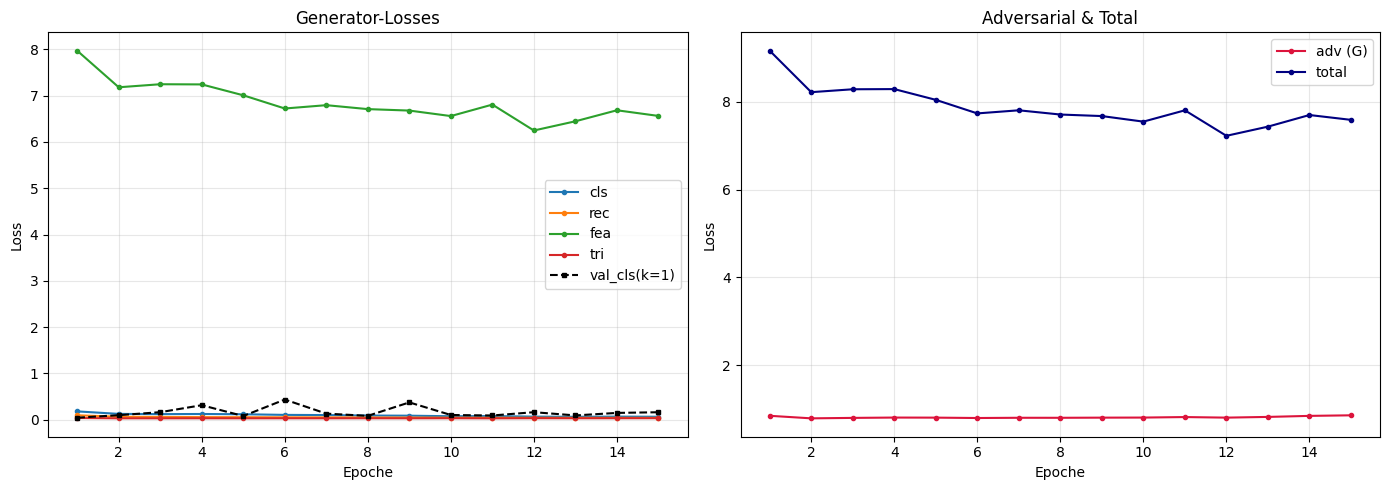

Kurven gespeichert


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(hist['total'])+1)
for kk in ['cls','rec','fea','tri']:
    axes[0].plot(ep, hist[kk], 'o-', ms=3, label=kk)
axes[0].plot(ep, hist['val_cls'], 's--', ms=3, label='val_cls(k=1)', color='k')
axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss')
axes[0].set_title('Generator-Losses'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, hist['adv'], 'o-', ms=3, color='crimson', label='adv (G)')
axes[1].plot(ep, hist['total'], 'o-', ms=3, color='navy', label='total')
axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Loss')
axes[1].set_title('Adversarial & Total'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'mirror_decoder_training_curves_fashionmnist.png', dpi=120, bbox_inches='tight')
plt.show()
print('Kurven gespeichert')

## 12. Qualitaetscheck — Rekonstruktion & CFE-Flip

CFE-Flip-Rate (k=1, dieser Batch): 100.0%


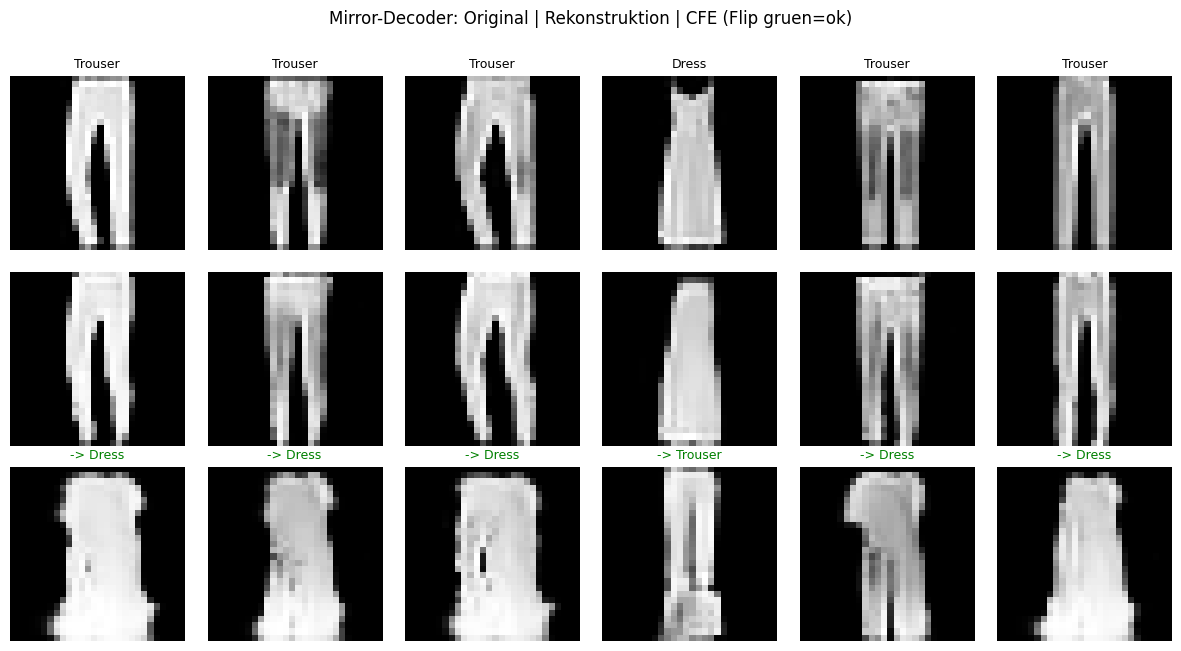

In [12]:
decoder.eval()
imgs, lbls = next(iter(val_loader))
imgs = imgs.to(DEVICE)
n = min(6, imgs.size(0))

with torch.no_grad():
    f1,f2,f3,f4 = extract_all_features(classifier, imgs)
    zs  = gap(f4); src = classifier(imgs).argmax(1); tgt = 1-src
    flk0,_ = compute_flk(f4, zs, Wm, bm, 0.0)
    xrec = tanh_to_img(decoder(flk0, f1, f2, f3, Wmat, 0.0, src, src))
    flk1, zk1 = compute_flk(f4, zs, Wm, bm, 1.0)
    xcfe = tanh_to_img(decoder(flk1, f1, f2, f3, Wmat, 1.0, src, tgt))
    cfe_pred = classifier(renormalise(xcfe)).argmax(1)
    flip = (cfe_pred == tgt).float().mean().item()

print(f'CFE-Flip-Rate (k=1, dieser Batch): {flip:.1%}')

fig, axes = plt.subplots(3, n, figsize=(n*2.0, 6.4))
orig = denormalise(imgs)
for i in range(n):
    axes[0,i].imshow(orig[i,0].cpu().numpy(), cmap='gray'); axes[0,i].axis('off')
    axes[0,i].set_title(f'{CLASS_NAMES[src[i].item()]}', fontsize=9)
    axes[1,i].imshow(xrec[i,0].cpu().numpy().clip(0,1), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(xcfe[i,0].cpu().numpy().clip(0,1), cmap='gray'); axes[2,i].axis('off')
    fl = 'green' if cfe_pred[i]==tgt[i] else 'red'
    axes[2,i].set_title(f'-> {CLASS_NAMES[tgt[i].item()]}', fontsize=9, color=fl)
axes[0,0].set_ylabel('Original',    fontsize=9)
axes[1,0].set_ylabel('Rekon (k=0)', fontsize=9)
axes[2,0].set_ylabel('CFE (k=1)',   fontsize=9)
plt.suptitle('Mirror-Decoder: Original | Rekonstruktion | CFE (Flip gruen=ok)', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'mirror_decoder_recon_check_fashionmnist.png', dpi=120, bbox_inches='tight')
plt.show()